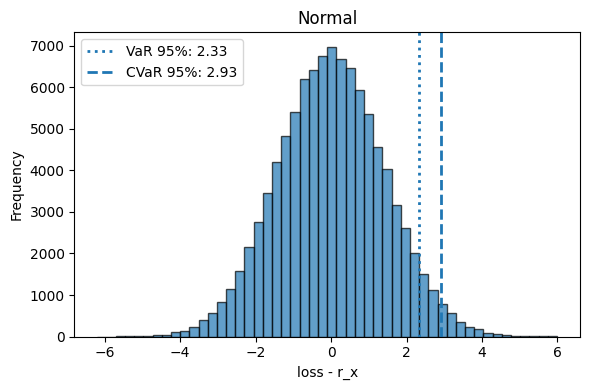

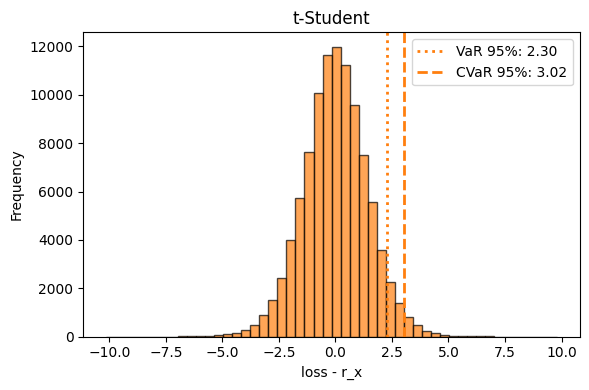

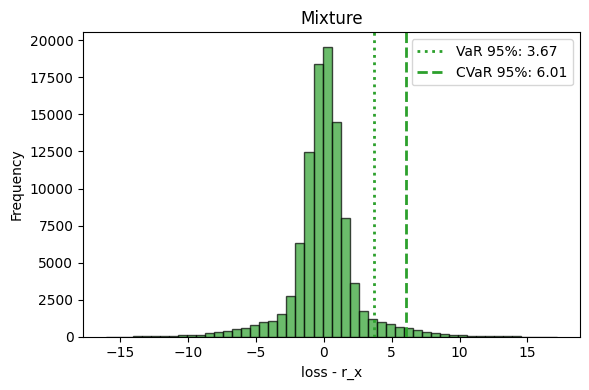

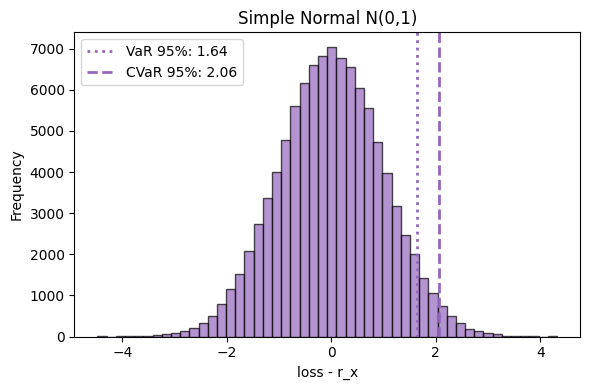

In [14]:
import numpy as np
from scipy.stats import multivariate_normal, multivariate_t

import matplotlib.pyplot as plt

# Parameters
n = 100000
mu = np.array([0, 0])
V = np.array([[1, 0], [0, 1]])
m = 12  # degrees of freedom for t-distribution

# 1. Multivariate Normal
samples_normal = multivariate_normal.rvs(mean=mu, cov=V, size=n)
loss_normal = np.sum(samples_normal, axis=1)

# 2. Multivariate t-Student
scale_t = ((m-2)/m) * V
samples_t = multivariate_t.rvs(loc=mu, shape=scale_t, df=m, size=n)
loss_t = np.sum(samples_t, axis=1)

# 3. Mixture of Normals
n1 = int(0.75 * n)
n2 = n - n1
samples_mix1 = multivariate_normal.rvs(mean=mu, cov=0.76**2 * V, size=n1)
samples_mix2 = multivariate_normal.rvs(mean=mu, cov=3**2 * V, size=n2)
samples_mixture = np.vstack([samples_mix1, samples_mix2])
loss_mixture = np.sum(samples_mixture, axis=1)

# 4. Simple Normal Distribution N(0,1)
samples_simple_normal = np.random.normal(loc=0, scale=1, size=n)
loss_simple_normal = samples_simple_normal  # 1D


# VaR and CVaR estimation (at 95%)
def var_cvar(loss, alpha=0.95):
    var = np.percentile(loss, 100*alpha)
    cvar = loss[loss >= var].mean()
    return var, cvar

var_n, cvar_n = var_cvar(loss_normal)
var_t, cvar_t = var_cvar(loss_t)
var_m, cvar_m = var_cvar(loss_mixture)
var_s, cvar_s = var_cvar(loss_simple_normal)

colors = ['tab:blue', 'tab:orange', 'tab:green']
# Plotting
# 1. Normal
plt.figure(figsize=(6, 4))
counts_n, bins_n, patches_n = plt.hist(loss_normal, bins=50, alpha=0.7, color=colors[0], edgecolor='black')
plt.axvline(var_n, color=colors[0], linestyle=':', linewidth=2, label=f'VaR 95%: {var_n:.2f}')
plt.axvline(cvar_n, color=colors[0], linestyle='--', linewidth=2, label=f'CVaR 95%: {cvar_n:.2f}')
plt.title('Normal')
plt.xlabel('loss - r_x')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

# 2. t-Student
plt.figure(figsize=(6, 4))
counts_t, bins_t, patches_t = plt.hist(loss_t, bins=50, alpha=0.7, color=colors[1], edgecolor='black')
plt.axvline(var_t, color=colors[1], linestyle=':', linewidth=2, label=f'VaR 95%: {var_t:.2f}')
plt.axvline(cvar_t, color=colors[1], linestyle='--', linewidth=2, label=f'CVaR 95%: {cvar_t:.2f}')
plt.title('t-Student')
plt.xlabel('loss - r_x')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

# 3. Mixture
plt.figure(figsize=(6, 4))
counts_m, bins_m, patches_m = plt.hist(loss_mixture, bins=50, alpha=0.7, color=colors[2], edgecolor='black')
plt.axvline(var_m, color=colors[2], linestyle=':', linewidth=2, label=f'VaR 95%: {var_m:.2f}')
plt.axvline(cvar_m, color=colors[2], linestyle='--', linewidth=2, label=f'CVaR 95%: {cvar_m:.2f}')
plt.title('Mixture')
plt.xlabel('loss - r_x')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

# 4. Simple Normal
plt.figure(figsize=(6, 4))
counts_s, bins_s, patches_s = plt.hist(loss_simple_normal, bins=50, alpha=0.7, color='tab:purple', edgecolor='black')
plt.axvline(var_s, color='tab:purple', linestyle=':', linewidth=2, label=f'VaR 95%: {var_s:.2f}')
plt.axvline(cvar_s, color='tab:purple', linestyle='--', linewidth=2, label=f'CVaR 95%: {cvar_s:.2f}')
plt.title('Simple Normal N(0,1)')
plt.xlabel('loss - r_x')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()  

